In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset
url = "https://data.cityofnewyork.us/api/views/6fi9-q3ta/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)


In [12]:
df.head()

,hour_beginning,location,Pedestrians,Towards Manhattan,Towards Brooklyn,weather_summary,temperature,precipitation,lat,long,events,Location1
0,04/30/2019 12:00:00 AM,Brooklyn Bridge,3,3,0,NaN,NaN,NaN,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
1,12/31/2019 10:00:00 PM,Brooklyn Bridge,10,9,1,cloudy,42.0,0.0005,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
2,12/31/2019 11:00:00 PM,Brooklyn Bridge,2,0,2,cloudy,42.0,0.0004,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
3,12/31/2019 09:00:00 PM,Brooklyn Bridge,12,0,12,cloudy,42.0,0.0036,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
4,04/01/2019 03:00:00 AM,Brooklyn Bridge,1,0,1,clear-night,36.0,0.0000,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"


##Problem 1

<ipython-input-13-3e311fcee934>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['hour_beginning'])


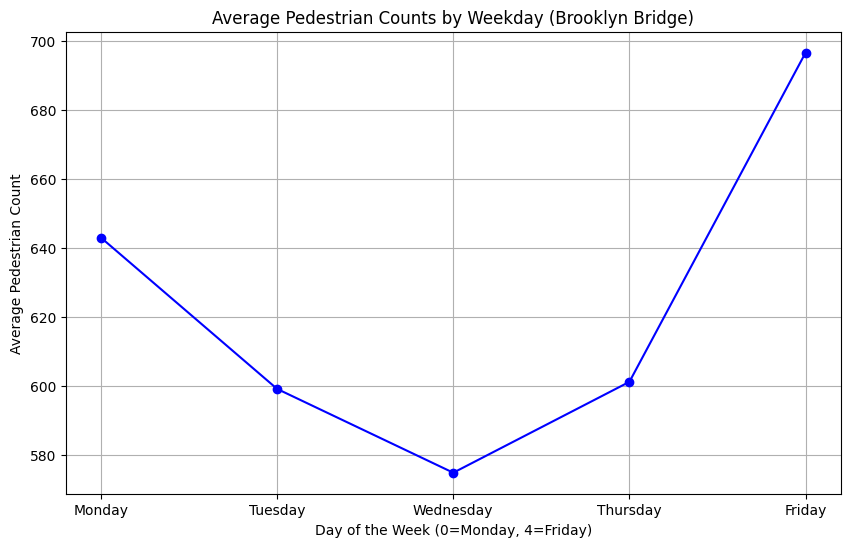

In [13]:
df['Date'] = pd.to_datetime(df['hour_beginning'])
df['Day_of_Week'] = df['Date'].dt.dayofweek

df_weekdays = df[df['Day_of_Week'] < 5]
weekday_counts = df_weekdays.groupby('Day_of_Week')['Pedestrians'].mean()

plt.figure(figsize=(10, 6))
weekday_counts.plot(kind='line', marker='o', color='b')
plt.title('Average Pedestrian Counts by Weekday (Brooklyn Bridge)')
plt.xlabel('Day of the Week (0=Monday, 4=Friday)')
plt.ylabel('Average Pedestrian Count')
plt.grid(True)
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
plt.show()

##Problem 2

Index(['Pedestrians', 'Towards Manhattan', 'Towards Brooklyn',
       'weather_summary', 'temperature', 'precipitation', 'Day_of_Week'],
      dtype='object')
Correlation between pedestrian counts and weather conditions in 2019:


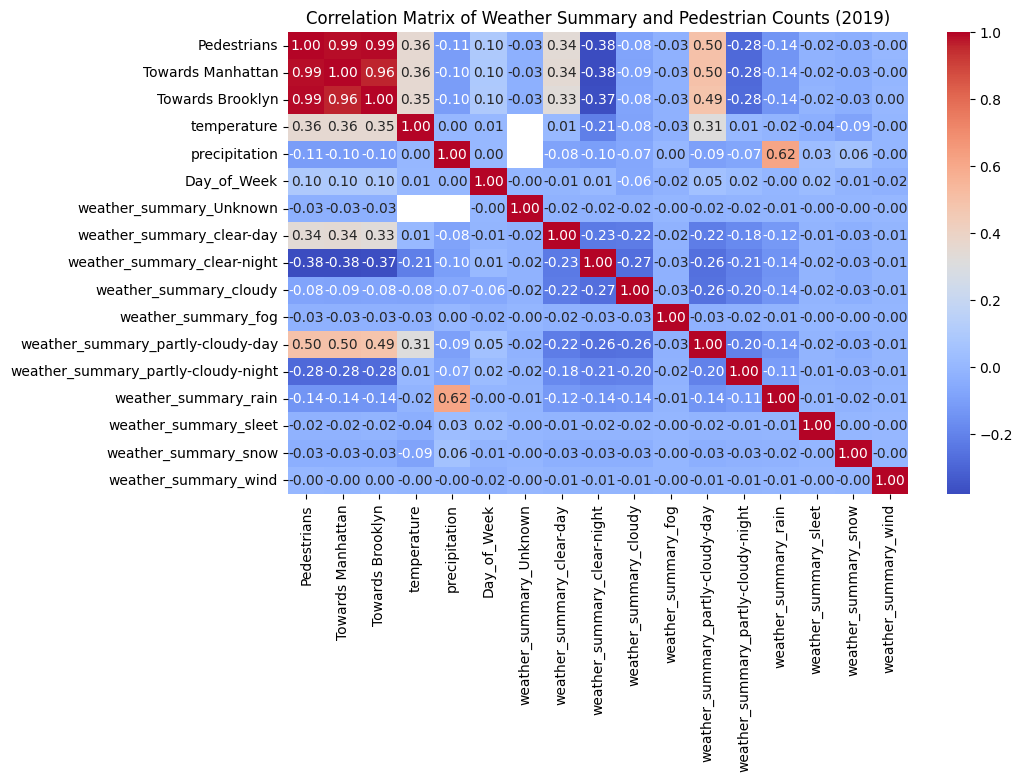

In [22]:
import seaborn as sns

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df_2019 = df.loc[df['Year'] == 2019].copy()
df_2019.loc[:, 'weather_summary'] = df_2019['weather_summary'].fillna('Unknown')
df_2019_encoded = df_2019.drop(columns=['hour_beginning', 'events', 'location', 'Location1', 'Date', 'Year', 'lat', 'long'])
print(df_2019_encoded.keys())
df_2019_encoded = pd.get_dummies(df_2019_encoded, columns=['weather_summary'])
corr_matrix = df_2019_encoded.corr()

pedestrian_weather_corr = corr_matrix['Pedestrians'].filter(like='weather_summary')

sorted_corr = pedestrian_weather_corr.sort_values()

print("Correlation between pedestrian counts and weather conditions in 2019:")
plt.figure(figsize=(10, 6))
sns.heatmap(df_2019_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Weather Summary and Pedestrian Counts (2019)')
plt.show()

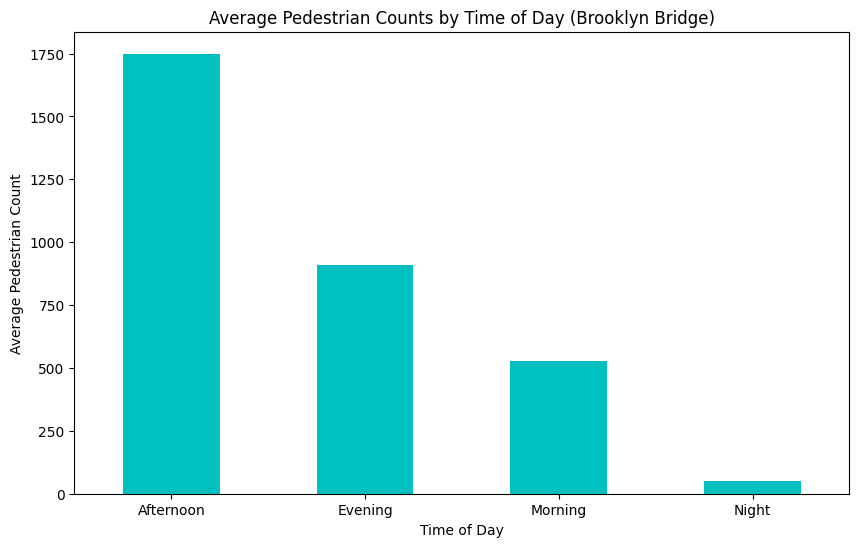

In [23]:
def categorize_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Hour'] = df['Date'].dt.hour
df['Time_of_Day'] = df['Hour'].apply(categorize_time_of_day)

time_of_day_counts = df.groupby('Time_of_Day')['Pedestrians'].mean()
plt.figure(figsize=(10, 6))
time_of_day_counts.plot(kind='bar', color='c')
plt.title('Average Pedestrian Counts by Time of Day (Brooklyn Bridge)')
plt.xlabel('Time of Day')
plt.ylabel('Average Pedestrian Count')
plt.xticks(rotation=0)
plt.show()